In [1]:
import sys
import numpy as np
import pandas as pd

In [2]:
%%cmd
python --version 

Microsoft Windows [Version 10.0.19044.3570]
(c) Microsoft Corporation. All rights reserved.

(fh) d:\dev\FH\notebooks>python --version 
Python 3.11.5

(fh) d:\dev\FH\notebooks>

*Python Version needs to match the path to the library* 

In [3]:
sys.path.append(r'C:\Program Files\DIgSILENT\PowerFactory 2020\Python\3.6')

In [4]:
import powerfactory as pf

# Load data

# Get PowerFactory

In [6]:
app = pf.GetApplicationExt()
if app is None:
    raise Exception('getting Powerfactory application failed')

ExitError: Exit with error code 3000

In [ ]:
app.Show()

In [ ]:
app.Hide()

# Project "Transformer"

## Activate Project

In [6]:
#define project name and study case    
projName = 'Transformator'
study_case = 'Berechnungsfall.IntCase'

#activate project
project = app.ActivateProject(projName)

## PowerFlow

In [7]:
#get load flow object and execute
oLoadflow=app.GetFromStudyCase('ComLdf') #get load flow object
oLoadflow.Execute() #execute load flow

0

In [8]:
#get the lines and print their loading
Lines=app.GetCalcRelevantObjects('*.ElmLne')
for line in Lines: #loop through list
    name = getattr(line, 'loc_name') # get name of the line
    value = getattr(line, 'c:loading') #get value for the loading
    #print results
    print('Loading of the line: %s = %.2f percent' %(name,value))

Loading of the line: Leitung = 18.93 percent


In [9]:
#get the buses and print their voltage
Buses=app.GetCalcRelevantObjects('*.ElmTerm')
for bus in Buses: #loop through list
    name = getattr(bus, 'loc_name') # get name of the bus
    amp = getattr(bus, 'm:u1') #get voltage magnitude
    phase = getattr(bus, 'm:phiu') #get voltage angle
    #print results
    print('Voltage at %s = %.2f pu %.2f deg' %(name,amp,phase))

Voltage at Haus = 1.04 pu -0.45 deg
Voltage at Mittelspannung = 1.00 pu 0.00 deg
Voltage at Sammelschiene = 1.04 pu -0.45 deg


In [17]:
#get the buses and print their voltage
Loads=app.GetCalcRelevantObjects('*.ElmLod')
for load in Loads: #loop through list
    name = getattr(load, 'loc_name') # get name of the bus
    #amp = getattr(load, 'm:ulnl') #get voltage magnitude
    plini = getattr(load, 'plini') #get load
    #print results
    print('Voltage at %s = %.2f kW' %(name,plini))

Voltage at Haus(1) = 0.50 kW


In [16]:
setattr(load, 'plini', 0.5)

# Project "SIM LV Demogrid Übung 2021"

In [5]:
#"SIM LV Demogrid Übung 2021"
project = app.ActivateProject("SIM LV Demogrid Übung 2021")

NameError: name 'app' is not defined

## loads

In [4]:
Loads=app.GetCalcRelevantObjects('*.ElmLod')
for load in Loads: #loop through list
    print(load.name)

NameError: name 'app' is not defined

## RMS simulation

In [9]:
comSim = app.GetFromStudyCase("ComSim")
comInc = app.GetFromStudyCase("ComInc")
#comLdf = app.GetFromStudyCase("ComLdf")

In [143]:
# Execute initial condition
comInc.Execute()

0

In [12]:
trafos=app.GetCalcRelevantObjects('*.ElmTr2')
trafo = trafos[0]

In [141]:
loads=app.GetCalcRelevantObjects('*.ElmLod')
load = loads[0]

<powerfactory.DataObject <l1>\z003yeph.IntUser\SIM LV Demogrid Übung 2021.IntPrj\Netzmodell.IntPrjfolder\Netzdaten.IntPrjfolder\Demogrid.ElmNet\Battery_1.ElmLod</l1>>

In [23]:
setattr(trafo,"nntap",3)

In [24]:
getattr(trafo,"nntap")

3

## loop

In [ ]:
for i in range(144):
    comSim.tstart = i
    comSim.tstop = i+1
    comSim.Execute()
    # check condition
    setattr(trafo, 'nntap', 3)

## single step

In [156]:
comSim.tstart = 1
comSim.tstop = 50

In [157]:
comSim.Execute()

0

In [158]:
setattr(load,"Pext",250)

In [114]:
direction = -1

In [137]:
# check if nntap or "nntapin" can be set during rms simulation
nntap= getattr(trafo, 'nntapin')
print(f"from nntap {nntap} to {nntap+1*direction}")
setattr(trafo, 'nntapin', nntap+1*direction)

from nntap -1 to -2


In [159]:
comSim.tstart = 51
comSim.tstop = 144

In [160]:
comSim.Execute()

0

In [68]:
# set Pext, Qext, nntap


Get Results from results set "Alle Berechnungsarten"

In [101]:
elmRes = app.GetFromStudyCase('*.ElmRes')    
app.ResLoadData(elmRes)

In [102]:
elmRes

<powerfactory.DataObject <l1>\z003yeph.IntUser\SIM LV Demogrid Übung 2021.IntPrj\Berechnungsfälle.IntPrjfolder\Berechnungsfall.IntCase\Alle Berechnungsarten.ElmRes</l1>>

In [103]:
NrRow = app.ResGetValueCount(elmRes,0)
print(NrRow)

145


In [104]:
oBus1 = app.GetCalcRelevantObjects('Home_4.ElmTerm')[0]

In [105]:
result_u_bus1 = np.zeros((NrRow))
ColIndex_u_bus1 = app.ResGetIndex(elmRes,oBus1,'m:u')
for i in range(NrRow):    
    result_u_bus1[i] = app.ResGetData(elmRes,i,ColIndex_u_bus1)[1]       

In [106]:
results = pd.DataFrame()
results['u_bus1'] = result_u_bus1

In [161]:
results

,u_bus1
0,0.991680
1,1.004178
2,1.004178
3,1.004168
4,1.004188
...,...
140,1.004325
141,1.004359
142,1.004346
143,1.004294


<AxesSubplot:>

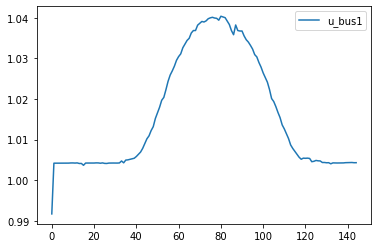

In [108]:
results.plot()

# Close app

In [110]:
app.Show()

In [109]:
app.Hide()

**Info: Stop Kernel to release PowerFactory**